## IdentifyOptimalClusterNumber
This script:
- Loads CLIP embeddings from the H5 data store and spatially joins points to LSOAs
- Cluster analysis:
    - Test whether there is a structure within the embeddings that would allow them to be broken down into sub-clusters
        - Silhouette scores
        - Elbow scores
        - Adjusted Rand Index
    - Decide on the optimal K
    - Run KMeans cluster analysis for K = 2..10
    - Save cluster assignments back to the H5 data store
- Examine the distribution of images across the SES-WOA score, within each cluster
- Plot a sample of images associated with each cluster number
- Spatial plotting to check whether the distribution of clusters is even or uneven

### Dependencies
**Prerequisites:** Script 3 (creates expanded image-level pickle). Also reads H5 store (from script 2) for sample images.

**Inputs:**
- `data/processed/one_row_per_image_cleaned.pkl` — expanded image rows (from script 3)
- `street_data.h5` (via `h5_filename`) — for displaying sample images per cluster
- CBS SES-WOA target (via `amsterdam_data.get_ses_woa()`) — for the score-distribution analysis
- `clustering_functions.py` — imports `global_k`, `RANDOM_STATE`

**Outputs:**
- `data/processed/one_row_per_image_cleaned_with_cluster_numbers.pkl` — adds `scene_cluster_2`..`scene_cluster_10`
- Figures: silhouette/elbow scores, UMAP visualisation, cluster spatial distribution

**Used by:** Scripts 6, 7, 8

In [1]:
import io
import os
from math import ceil

import contextily as cx
import geopandas as gpd
import h5py
import pandas as pd
from PIL import Image
import umap
import seaborn as sns # Use a seaborn palette later
from matplotlib.colors import ListedColormap

In [2]:
from clustering_functions import *
from directory_filepaths import *
from amsterdam_data import get_ses_woa

print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Will write outputs to {outputs_dir}")

Number of clusters (defined in clustering_functions.py) = 5
Will write outputs to ../outputs


In [3]:
# Load expanded dataframe (one row per image) produced by script 3
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")
expanded_gdf


Loaded 200192 image rows


,point_id,latitude,longitude,geometry,buurtcode,buurtnaam,embedding,image_path
0,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.012054443, 0.01197052, 0.03161621, 0.02873...",../raw/panorama_images/TMX7316010203-002266_pa...
1,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[0.013656616, 0.002614975, -0.0056610107, -0.0...",../raw/panorama_images/TMX7316010203-002266_pa...
2,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.031982422, 0.018936157, -0.019088745, 0.00...",../raw/panorama_images/TMX7316010203-002266_pa...
3,0,52.338331,5.135787,POINT (5.1357867600834 52.3383313335052),BU00346602,Duin Zuid,"[-0.06561279, 0.034851074, -0.017913818, -0.01...",../raw/panorama_images/TMX7316010203-002266_pa...
4,1,52.338017,5.136135,POINT (5.13613513993084 52.3380172367688),BU00346602,Duin Zuid,"[-0.028701782, 0.01058197, -0.006225586, -0.00...",../raw/panorama_images/TMX7316010203-002266_pa...
...,...,...,...,...,...,...,...,...
200187,50046,52.345222,4.978260,POINT (4.97826022008138 52.3452218426547),BU03840105,Vlindertuin,"[-0.029342651, -0.0031089783, -0.0418396, 0.01...",../raw/panorama_images/TMX7316060226-000019_pa...
200188,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.052246094, 0.028701782, -0.013313293, 0.01...",../raw/panorama_images/TMX7316060226-000019_pa...
200189,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.022521973, -0.005554199, -0.027404785, 0.0...",../raw/panorama_images/TMX7316060226-000019_pa...
200190,50047,52.345339,4.978033,POINT (4.97803298647454 52.3453393170714),BU03840104,Scheepskwartier,"[-0.02230835, 0.022781372, -0.002948761, 0.037...",../raw/panorama_images/TMX7316060226-000019_pa...


# Test optimal cluster numbers

In [4]:
all_embeddings = np.stack(expanded_gdf['embedding'].values)
print(f"Embedding matrix shape: {all_embeddings.shape}")

Embedding matrix shape: (200192, 512)


### Examine silhouette scores

In [5]:
best_k, inertias, sil_scores = find_optimal_k_silhoutte_fast(all_embeddings)
print(best_k)

3


### Examine elbow scores

In [6]:
optimal_k, ks, inertias = find_optimal_k_elbow(all_embeddings)
# # plot_elbow(ks, inertias, optimal_k)


Detected elbow at k = 8


### Plot together elbow and silhouette scores

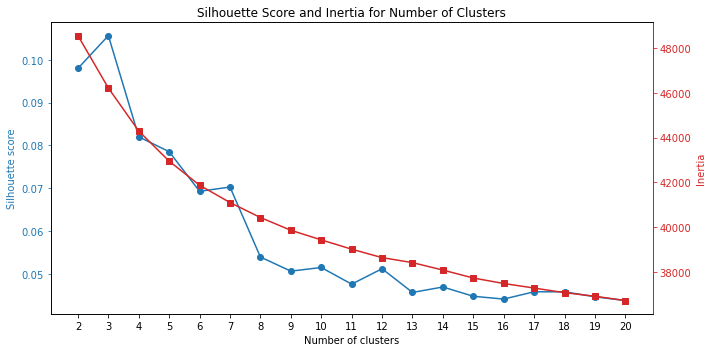

In [7]:
ks = range(2, 21)

fig, ax1 = plt.subplots(figsize=(10, 5))


# ----- Add title here -----
plt.title("Silhouette Score and Inertia for Number of Clusters")


# Silhouette scores (left axis, blue)
ax1.plot(ks, sil_scores, marker='o', color='tab:blue')
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette score", color='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax1.set_xticks(range(2, 21))

#ax1.axvline(best_k, linestyle='--', color='tab:blue', label=f'Best silhouette (k={best_k})')
#ax1.axvline(optimal_k, linestyle='--', color='tab:red', label=f'Elbow (k={optimal_k})')
#ax1.legend(loc='upper right')

# Inertia (right axis, red)
ax2 = ax1.twinx()
ax2.plot(ks, inertias, marker='s', color='tab:red')
ax2.set_ylabel("Inertia", color='tab:red')
ax2.tick_params(axis='y', colors='tab:red')
ax2.spines['right'].set_color('tab:red')

plt.tight_layout()

# Save to PDF
plt.savefig(os.path.join(outputs_dir, "5-Silhoutte_and_elbow_scores.pdf"), format="pdf")

# Display on screen
plt.show()


### Assess clustering stability using the adjusted rand index

(_This isn't used in the paper any more_)

In [8]:
#mean_aris = []
#std_aris = []
#for k in range(2,15):
#    mean_ari, std_ari, _ = clustering_stability(all_embeddings, k)
#    # print(f"k={k}: ARI = {mean_ari:.2f} ± {std_ari:.2f}")
#    mean_aris.append(mean_ari)
#    std_aris.append(std_ari)

In [9]:
#fig,ax=plt.subplots(figsize=(6,3.5))
#ax.plot(range(2,15), mean_aris)
#ax.set_xlabel("Number of clusters")
#ax.set_ylabel("ARI")

# Run cluster analysis with optimal k
Add a column to the dataframe showing which cluster the image would fall within, for cluster numbers between 2 and 10

In [10]:
for k in range(2,11):
    #print(k)
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(all_embeddings)
    expanded_gdf[f'scene_cluster_{k}'] = labels + 1    

### Check UMAP low-dimensional projection

In [11]:
embeddings = np.vstack(expanded_gdf["embedding"].values)   # shape (N, 512)
             # string labels
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',   # recommended for CLIP embeddings
    random_state=RANDOM_STATE)

emb_2d = reducer.fit_transform(embeddings)  # shape (N, 2)

expanded_gdf['umap_x'] = emb_2d[:, 0]
expanded_gdf['umap_y'] = emb_2d[:, 1]

/opt/homebrew/anaconda3/envs/streetview-deprivation-amsterdam/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Plot UMAP

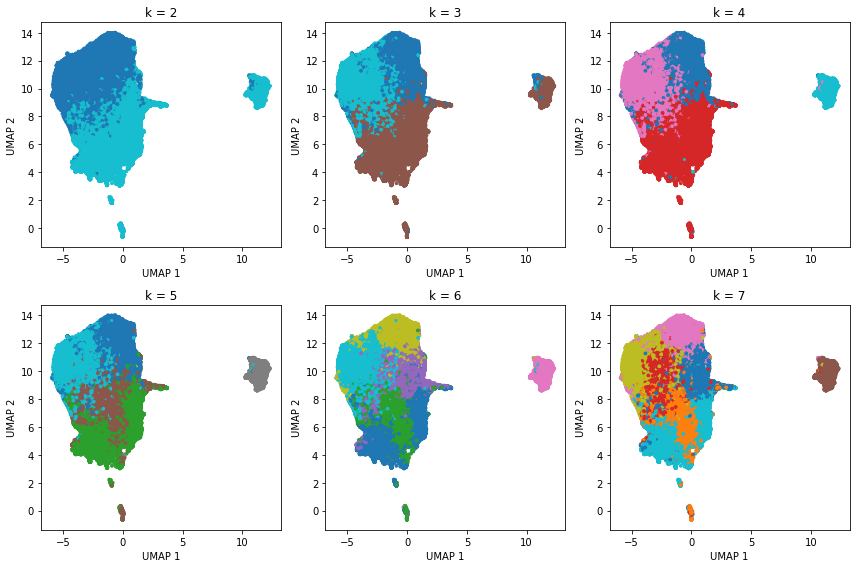

In [12]:
ks = range(2, 8)  # k = 2 to 10
n_plots = len(ks)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axs = axs.flatten()

for i, k in enumerate(ks):
    ax = axs[i]
    labels = expanded_gdf[f'scene_cluster_{k}']

    sc = ax.scatter(expanded_gdf['umap_x'], expanded_gdf['umap_y'], c=labels, cmap='tab10', s=8)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

# Turn off any unused axes
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()

# ---- Save to PNG ----
plt.savefig(os.path.join(outputs_dir, "5-umap_visualisation.png"), dpi=300)

# Display
plt.show()

### Save

In [13]:
expanded_gdf.to_pickle(os.path.join(data_dir, "one_row_per_image_cleaned_with_cluster_numbers.pkl"))

In [14]:
# for num in range(1,8):
#     print(num)
#     print(len(expanded_gdf[expanded_gdf['scene_cluster_7']==num]))

### Display some images in each cluster

Set `DISPLAY_IMAGES` below to True if you want to actually see the images (_I don't do this because it makes the notebook huge_). Images are saved to file

In [15]:
DISPLAY_IMAGES = False  # Set True to render sample images inline in the notebook

total_k = global_k  # k defined in clustering_functions.py
n_images = 70
cols = 7

with h5py.File(h5_filename, "r") as f:
    h5_point_ids = f["point_id"][:]
    h5_image_paths = f["image_paths"][:]
    images_jpeg = f["images_jpeg"]

    # point_id values have gaps (0..19195), so they don't equal H5 row indices (0..18896)
    pid_to_h5row = {int(pid): i for i, pid in enumerate(h5_point_ids)}

    for this_cluster_num in range(1, total_k + 1):
        this_cluster = expanded_gdf[expanded_gdf[f"scene_cluster_{total_k}"] == this_cluster_num]
        sample = this_cluster.sample(n=min(n_images, len(this_cluster)), random_state=RANDOM_STATE)

        images = []
        for _, row in sample.iterrows():
            h5_row = pid_to_h5row.get(int(row["point_id"]))
            if h5_row is None:
                continue
            target_path = row["image_path"]

            for slot in range(4):
                stored = h5_image_paths[h5_row, slot].decode("ascii").rstrip("\x00")
                if stored == target_path:
                    jpeg_bytes = images_jpeg[h5_row, slot]
                    if isinstance(jpeg_bytes, np.void):
                        jpeg_bytes = jpeg_bytes.tobytes()

                    img = Image.open(io.BytesIO(jpeg_bytes)).convert("RGB")
                    # Optinoally reduce image size (so the notebook isn't quite so big, although it's still huge if the images are left in)
                    #img = img.resize((128, 128))   # shrink images so the notebook doesn't get too big
                    images.append(img)
                    break

        if not images:
            print(f"Cluster {this_cluster_num}: no images matched, skipping")
            continue

        n_rows = ceil(len(images) / cols)
        fig, axes = plt.subplots(n_rows, cols, figsize=(cols * 2, n_rows * 2))
        axes = axes.flatten()

        for ax, img in zip(axes, images):
            ax.imshow(img)
            ax.axis('off')
        for ax in axes[len(images):]:
            ax.axis('off')

        fig.suptitle(f"Cluster {this_cluster_num} (k={total_k})", y=1.005)
        plt.tight_layout()

        # Always save to file (outputs/5-cluster{N}_sample.png)
        #fig.savefig(os.path.join(outputs_dir, f"5-cluster{this_cluster_num}_sample.png"), dpi=150, bbox_inches="tight")
        fig.savefig(os.path.join(outputs_dir, f"5-cluster{this_cluster_num}_sample.jpg"), bbox_inches="tight")
        print(f"Saved cluster {this_cluster_num} sample to {outputs_dir}/5-cluster{this_cluster_num}_sample.png")

        if DISPLAY_IMAGES:
            plt.show()
        else:
            plt.close(fig)

Saved cluster 1 sample to ../outputs/5-cluster1_sample.png


Saved cluster 2 sample to ../outputs/5-cluster2_sample.png


Saved cluster 3 sample to ../outputs/5-cluster3_sample.png


Saved cluster 4 sample to ../outputs/5-cluster4_sample.png


Saved cluster 5 sample to ../outputs/5-cluster5_sample.png


## Examine distribution of images in each cluster across SES-WOA scores

In [16]:
# SES-WOA target (the deprivation measure); keyed on buurtcode (JOIN_KEY)
ses = get_ses_woa()

# Filter to buurten present in our dataset
buurtcodes = expanded_gdf[JOIN_KEY].unique()
ses_ams = ses[ses[JOIN_KEY].isin(buurtcodes)].copy()

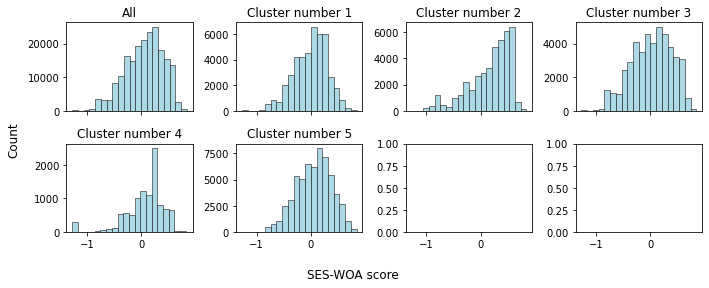

In [17]:
expanded_gdf_with_ses = pd.merge(left=expanded_gdf, right=ses_ams[[JOIN_KEY, 'ses_woa_score']], on=JOIN_KEY)

ses_column = 'ses_woa_score'

fig, axs = plt.subplots(ncols=4, nrows=2, sharex=True, sharey=False, figsize=(10, 4))
axs = axs.flatten()

axs[0].hist(expanded_gdf_with_ses[ses_column], bins=20, edgecolor="black", linewidth=0.5, color="lightblue")
axs[0].set_title("All")

for cluster_number in range(1, total_k+1):
    cluster = expanded_gdf_with_ses[expanded_gdf_with_ses[f"scene_cluster_{total_k}"] == cluster_number]
    axs[cluster_number].hist(cluster[ses_column], bins=20, edgecolor="black", linewidth=0.5, color="lightblue")
    axs[cluster_number].set_title(f"Cluster number {cluster_number}")

# # Switch off any unused axes
# for ax in axs[total_k+1:]:
#     ax.axis("off")

# Global labels
fig.supxlabel("SES-WOA score")
fig.supylabel("Count")

plt.tight_layout()

# Spatial plots

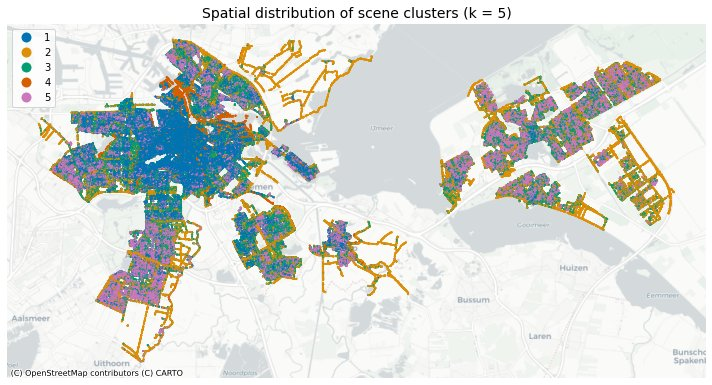

In [18]:
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    expanded_gdf,
    geometry=gpd.points_from_xy(
        expanded_gdf.longitude,
        expanded_gdf.latitude),
    crs="EPSG:4326")#  # WGS84)
gdf = gdf.to_crs(epsg=3857)





fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column=f"scene_cluster_{total_k}",
    categorical=True,
    legend=True,
    markersize=0.7,
    cmap=ListedColormap(sns.color_palette("colorblind", n_colors=total_k)),
    alpha=1.0)

# Add basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
ax.set_title(f"Spatial distribution of scene clusters (k = {total_k})", fontsize=14)

plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "5-cluster_spatial_distribution.png"), dpi=150, bbox_inches="tight")
show_jpeg()